# ITT Pulmon de Oriente - Seguridad T1 2026, Cali

## Version parcial de seguridad

- Zona agregada: Pulmon de Oriente
- Corte principal: primer trimestre de 2026
- Dimension implementada: Seguridad
- Indicadores: Homicidios y Hurtos
- Nota metodologica: el dato de homicidios T1 2026 se estima con el promedio observado de T1 2023-2025 mientras llega el dato oficial


## Celda 1 - Instalacion de dependencias


In [3]:
# Descomentar en Colab
!pip install geopandas pyproj shapely openpyxl matplotlib seaborn folium -q


## Celda 2 - Importaciones y configuracion


In [4]:
import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

sns.set_theme(style='whitegrid')
BG = '#F7F7F5'
COL_2023 = '#42A5F5'
COL_2024 = '#1B4F8A'
COL_2025 = '#E53935'
COL_2026 = '#2E7D32'
COLORS = {2023: COL_2023, 2024: COL_2024, 2025: COL_2025, 2026: COL_2026}


## Celda 3A - Subida ZIP (Colab)


In [5]:
# Ejecutar solo en Colab si necesitas subir el ZIP desde tu PC
try:
    from google.colab import files
    print('Selecciona Pulmon_De_Oriente_2026.zip...')
    uploaded = files.upload()
    if uploaded:
        zip_name = next(iter(uploaded.keys()))
        out_dir = '/content/Pulmon_De_Oriente_2026'
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_name, 'r') as zf:
            zf.extractall(out_dir)
        print(f'ZIP extraido en: {out_dir}')
except Exception as e:
    print('Celda opcional fuera de Colab:', e)


Selecciona Pulmon_De_Oriente_2026.zip...


Saving Pulmon_De_Oriente_2026.zip to Pulmon_De_Oriente_2026.zip
ZIP extraido en: /content/Pulmon_De_Oriente_2026


## Celda 3 - Parametros, rutas y umbrales

Se usan refs trimestrales provisionales calibrados para esta salida parcial de seguridad.


In [6]:
BASE = '/content/Pulmon_De_Oriente_2026/Pulmon_De_Oriente_2026/'
# BASE = './data/itt_pulmon_oriente/Pulmon_De_Oriente_2026_unzipped/Pulmon_De_Oriente_2026/'

PATHS = {
    'zona': os.path.join(BASE, 'shape_Pulmon_O', 'poligonos_oriente.shp'),
    'homicidios_hist': os.path.join(BASE, 'Geosjon_Pulmon_O', 'GeoJson_SSJ', 'HOMICIDIOS_2023_2025_PULMON.geojson'),
    'hurtos_t1': os.path.join(BASE, 'geojson_Observatorio_Seguridad_2026', 'DATIC_hurtos_2023_2026T1_Pulmon_O.geojson'),
}

ANIOS_HIST = [2023, 2024, 2025]
ANO_OBJ = 2026
TRIMESTRE_OBJ = 1

# Umbrales trimestrales provisionales para esta salida parcial.
REFS = {
    'homicidios': (15.0, 30.0, True),
    'hurtos': (250.0, 1300.0, True),
}

EXPORT_PATH = 'ITT_Pulmon_Oriente_Seguridad_T1_2026.xlsx'


## Celda 4 - Carga de datos


In [7]:
def validar_rutas(paths):
    faltantes = [k for k, v in paths.items() if not os.path.exists(v)]
    if faltantes:
        raise FileNotFoundError(f'No se encontraron estas rutas: {faltantes}')

def estandarizar_columnas(gdf):
    gdf = gdf.copy()
    gdf.columns = [str(c).strip().lower() for c in gdf.columns]
    return gdf

def pick_col(df, candidatos, requerido=True):
    cols = set(df.columns)
    for c in candidatos:
        if c in cols:
            return c
    if requerido:
        raise KeyError(f'No se encontro ninguna columna entre: {candidatos}')
    return None

def to_wgs(gdf):
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)
    return gdf.to_crs(epsg=4326)

def filtrar_en_zona(gdf_eventos, gdf_zona):
    pts = gdf_eventos[gdf_eventos.geometry.notna()].copy()
    zona = gdf_zona[['geometry']].copy()
    filtrado = gpd.sjoin(pts, zona, how='inner', predicate='within')
    return filtrado.drop(columns=['index_right'], errors='ignore')

validar_rutas(PATHS)

gdf_zona = estandarizar_columnas(gpd.read_file(PATHS['zona']))
gdf_zona = to_wgs(gdf_zona)
gdf_zona = gdf_zona[['geometry']].dissolve().reset_index(drop=True)

gdf_homicidios = estandarizar_columnas(gpd.read_file(PATHS['homicidios_hist']))
gdf_homicidios = to_wgs(gdf_homicidios)
gdf_homicidios = filtrar_en_zona(gdf_homicidios, gdf_zona)

gdf_hurtos = estandarizar_columnas(gpd.read_file(PATHS['hurtos_t1']))
gdf_hurtos = to_wgs(gdf_hurtos)
gdf_hurtos = filtrar_en_zona(gdf_hurtos, gdf_zona)

print('Zona cargada:', len(gdf_zona), 'geometria agregada')
print('Homicidios historicos filtrados a la zona:', len(gdf_homicidios))
print('Hurtos T1 filtrados a la zona:', len(gdf_hurtos))


Zona cargada: 1 geometria agregada
Homicidios historicos filtrados a la zona: 287
Hurtos T1 filtrados a la zona: 5171


## Celda 5 - Mapa de geolocalizacion


In [14]:
centroid = gdf_zona.geometry.centroid.iloc[0]
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=13, tiles='CartoDB positron')

folium.GeoJson(
    gdf_zona.to_json(),
    name='Pulmon de Oriente',
    style_function=lambda x: {'color': '#1B4F8A', 'weight': 3, 'fillColor': '#42A5F5', 'fillOpacity': 0.12}
).add_to(m)

fecha_hurtos = pick_col(gdf_hurtos, ['fecha_hech', 'fecha_hecho', 'fecha'])
gdf_hurtos['fecha_tmp'] = pd.to_datetime(gdf_hurtos[fecha_hurtos], errors='coerce')
gdf_hurtos['ano_tmp'] = gdf_hurtos['fecha_tmp'].dt.year
ano_col_hurtos = pick_col(gdf_hurtos, ['anio', 'ano'], requerido=False)
if ano_col_hurtos is not None:
    ano_num = pd.to_numeric(gdf_hurtos[ano_col_hurtos].astype(str).str.replace(',', '.', regex=False), errors='coerce')
    gdf_hurtos.loc[ano_num.notna(), 'ano_tmp'] = ano_num[ano_num.notna()].astype(int)
gdf_hurtos['mes_tmp'] = gdf_hurtos['fecha_tmp'].dt.month
hurtos_2026_mapa = gdf_hurtos[(gdf_hurtos['ano_tmp'] == 2026) & (gdf_hurtos['mes_tmp'].between(1, 3))].copy()

for _, row in hurtos_2026_mapa.iterrows():
    popup = folium.Popup(
        f"<b>Barrio:</b> {row.get('nom_barrio', '')}<br>"
        f"<b>Direccion:</b> {row.get('direccion', '')}<br>"
        f"<b>Fecha:</b> {row.get('fecha_hech', row.get('fecha_hecho', ''))}<br>"
        f"<b>Modalidad:</b> {row.get('modalidad', '')}",
        max_width=300,
    )
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        color=COL_2026,
        fill=True,
        fill_color=COL_2026,
        fill_opacity=0.75,
        weight=1,
        popup=popup,
    ).add_to(m)

print(f'Hurtos T1 2026 mapeados: {len(hurtos_2026_mapa)}')
folium.LayerControl().add_to(m)
m


Hurtos T1 2026 mapeados: 1164


## Celda 6 - Procesamiento de indicadores de seguridad


In [9]:
def normalizar_fecha(s):
    return pd.to_datetime(s, errors='coerce')

def contar_t1_por_ano(gdf, fecha_cols, ano_cols=None, anios=None):
    df = gdf.copy()
    fecha_col = pick_col(df, fecha_cols)
    df['fecha_tmp'] = normalizar_fecha(df[fecha_col])
    df = df[df['fecha_tmp'].notna()].copy()
    df['ano'] = df['fecha_tmp'].dt.year
    if ano_cols:
        ano_col = pick_col(df, ano_cols, requerido=False)
        if ano_col is not None:
            ano_num = pd.to_numeric(df[ano_col].astype(str).str.replace(',', '.', regex=False), errors='coerce')
            df.loc[ano_num.notna(), 'ano'] = ano_num[ano_num.notna()].astype(int)
    df['mes_num'] = df['fecha_tmp'].dt.month
    df = df[df['mes_num'].between(1, 3)].copy()
    if anios is not None:
        df = df[df['ano'].isin(anios)].copy()
    return df.groupby('ano').size().rename('casos').reset_index()

soporte_homicidios = contar_t1_por_ano(
    gdf_homicidios,
    fecha_cols=['fecha_hech', 'fecha_hecho', 'fecha'],
    anios=ANIOS_HIST,
).rename(columns={'casos': 'homicidios_t1'})

soporte_hurtos = contar_t1_por_ano(
    gdf_hurtos,
    fecha_cols=['fecha_hech', 'fecha_hecho', 'fecha'],
    ano_cols=['anio', 'ano'],
    anios=ANIOS_HIST + [ANO_OBJ],
).rename(columns={'casos': 'hurtos_t1'})

homicidios_estimado_2026 = round(soporte_homicidios['homicidios_t1'].mean(), 2)
hurtos_2026 = float(soporte_hurtos.loc[soporte_hurtos['ano'] == ANO_OBJ, 'hurtos_t1'].iloc[0])
hurtos_2025 = float(soporte_hurtos.loc[soporte_hurtos['ano'] == 2025, 'hurtos_t1'].iloc[0])
homicidios_2025 = float(soporte_homicidios.loc[soporte_homicidios['ano'] == 2025, 'homicidios_t1'].iloc[0])

resultado_2026 = pd.DataFrame([
    {
        'ano': ANO_OBJ,
        'trimestre': 'T1',
        'homicidios': homicidios_estimado_2026,
        'homicidios_fuente': 'estimado_promedio_t1_2023_2025',
        'hurtos': hurtos_2026,
        'hurtos_fuente': 'observado',
    }
])

print('Soporte historico T1 para estimar homicidios 2026:')
display(soporte_homicidios)
print('\nSoporte T1 de hurtos 2023-2026:')
display(soporte_hurtos)
print('\nResultado principal T1 2026:')
display(resultado_2026)


Soporte historico T1 para estimar homicidios 2026:


,ano,homicidios_t1
0,2023,24
1,2024,18
2,2025,25



Soporte T1 de hurtos 2023-2026:


,ano,hurtos_t1
0,2023,434
1,2024,377
2,2025,288
3,2026,1164



Resultado principal T1 2026:


,ano,trimestre,homicidios,homicidios_fuente,hurtos,hurtos_fuente
0,2026,T1,22.33,estimado_promedio_t1_2023_2025,1164.0,observado


## Celda 7 - Score de seguridad T1 2026


In [10]:
def score_ref(valor, ref_min, ref_max, inverso):
    if ref_max == ref_min:
        return 100.0
    raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
    return 100 - raw if inverso else raw

def nivel_itt(x):
    if x < 40:
        return 'Emergencia'
    if x < 60:
        return 'Consolidacion'
    if x < 80:
        return 'Avance'
    return 'Transformacion'

resultado_2026['score_homicidios'] = resultado_2026['homicidios'].apply(lambda v: score_ref(v, *REFS['homicidios']))
resultado_2026['score_hurtos'] = resultado_2026['hurtos'].apply(lambda v: score_ref(v, *REFS['hurtos']))
resultado_2026['score_seguridad'] = resultado_2026[['score_homicidios', 'score_hurtos']].mean(axis=1)
resultado_2026['nivel'] = resultado_2026['score_seguridad'].apply(nivel_itt)

print('Score de Seguridad T1 2026:')
display(resultado_2026[['ano', 'trimestre', 'homicidios', 'hurtos', 'score_homicidios', 'score_hurtos', 'score_seguridad', 'nivel']].round(2))
print('\nNota: homicidios 2026 T1 = promedio de T1 2023-2025 mientras llega el dato oficial.')


Score de Seguridad T1 2026:


,ano,trimestre,homicidios,hurtos,score_homicidios,score_hurtos,score_seguridad,nivel
0,2026,T1,22.33,1164.0,51.13,12.95,32.04,Emergencia



Nota: homicidios 2026 T1 = promedio de T1 2023-2025 mientras llega el dato oficial.


## Celda 8 - Cards de metricas clave


In [11]:
def safe_pct(new, old):
    if old == 0:
        return 0.0
    return (new - old) / old * 100

row_2026 = resultado_2026.iloc[0]
var_hom = safe_pct(row_2026['homicidios'], homicidios_2025)
var_hur = safe_pct(row_2026['hurtos'], hurtos_2025)

print('Pulmon de Oriente - Seguridad T1 2026')
print()
print(f"Homicidios T1 2026: {row_2026['homicidios']:.2f} ({row_2026['homicidios_fuente']}) | variacion vs T1 2025: {var_hom:.1f}%")
print(f"Hurtos T1 2026: {row_2026['hurtos']:.0f} ({row_2026['hurtos_fuente']}) | variacion vs T1 2025: {var_hur:.1f}%")
print(f"Score Seguridad T1 2026: {row_2026['score_seguridad']:.1f} | nivel: {row_2026['nivel']}")


Pulmon de Oriente - Seguridad T1 2026

Homicidios T1 2026: 22.33 (estimado_promedio_t1_2023_2025) | variacion vs T1 2025: -10.7%
Hurtos T1 2026: 1164 (observado) | variacion vs T1 2025: 304.2%
Score Seguridad T1 2026: 32.0 | nivel: Emergencia


## Celda 9 - Heatmap de la dimension Seguridad T1 2026


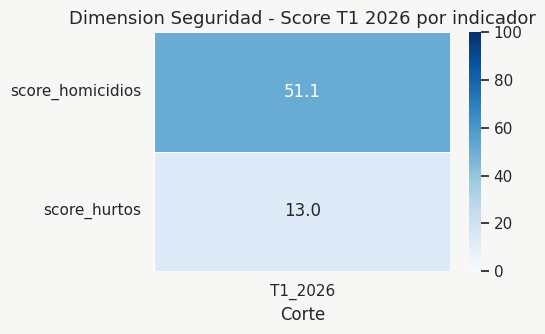

In [12]:
heat = resultado_2026[['score_homicidios', 'score_hurtos']].T
heat.columns = ['T1_2026']
heat.index = ['score_homicidios', 'score_hurtos']

fig, ax = plt.subplots(figsize=(5.5, 3.5), facecolor=BG)
sns.heatmap(heat, annot=True, fmt='.1f', cmap='Blues', linewidths=.5, cbar=True, ax=ax, vmin=0, vmax=100)
ax.set_title('Dimension Seguridad - Score T1 2026 por indicador', fontsize=13)
ax.set_xlabel('Corte')
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


## Celda 10 - Soporte historico trimestral


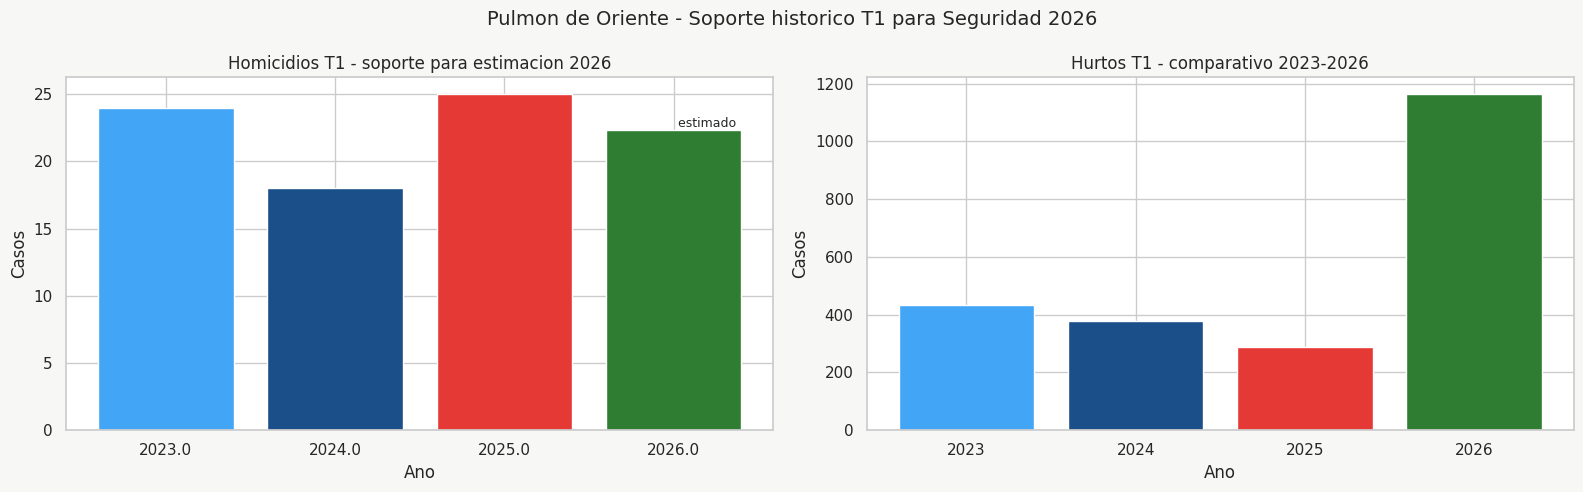

In [13]:
hom_plot = soporte_homicidios.copy()
hom_plot.loc[len(hom_plot)] = [2026, homicidios_estimado_2026]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)

axes[0].bar(hom_plot['ano'].astype(str), hom_plot['homicidios_t1'], color=[COLORS.get(int(a), COL_2026) for a in hom_plot['ano']])
axes[0].set_title('Homicidios T1 - soporte para estimacion 2026')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Casos')
axes[0].text(len(hom_plot) - 1, homicidios_estimado_2026, ' estimado', va='bottom', ha='left', fontsize=9)

axes[1].bar(soporte_hurtos['ano'].astype(str), soporte_hurtos['hurtos_t1'], color=[COLORS.get(int(a), COL_2026) for a in soporte_hurtos['ano']])
axes[1].set_title('Hurtos T1 - comparativo 2023-2026')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Casos')

plt.suptitle('Pulmon de Oriente - Soporte historico T1 para Seguridad 2026', fontsize=14)
plt.tight_layout()
plt.show()


## Celda 11 - Exportar a Excel


In [ ]:
meta = pd.DataFrame([
    {'campo': 'zona', 'valor': 'Pulmon de Oriente'},
    {'campo': 'alcance', 'valor': 'Dimension Seguridad T1 2026'},
    {'campo': 'unidad_analisis', 'valor': 'Zona agregada'},
    {'campo': 'corte_principal', 'valor': 'Primer trimestre de 2026'},
    {'campo': 'homicidios_2026', 'valor': 'Estimado con promedio de T1 2023-2025'},
    {'campo': 'hurtos_2026', 'valor': 'Dato observado filtrado espacialmente a Pulmon de Oriente'},
    {'campo': 'refs_homicidios_t1', 'valor': '15.0 a 30.0'},
    {'campo': 'refs_hurtos_t1', 'valor': '250.0 a 1300.0'},
])

with pd.ExcelWriter(EXPORT_PATH, engine='openpyxl') as writer:
    soporte_homicidios.to_excel(writer, sheet_name='soporte_homicidios', index=False)
    soporte_hurtos.to_excel(writer, sheet_name='soporte_hurtos', index=False)
    resultado_2026.round(2).to_excel(writer, sheet_name='seguridad_t1_2026', index=False)
    meta.to_excel(writer, sheet_name='metodologia', index=False)

print(f'Archivo exportado: {EXPORT_PATH}')
